In [35]:
import pandas as pd
import re
import string
import nltk
import seaborn as sns 
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\IRUL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\IRUL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\IRUL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Loading Dataset

In [18]:
# Menampilkan ringkasan informasi dari dataset
df = pd.read_csv('noice_app_reviews.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12223 entries, 0 to 12222
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   reviewId              12223 non-null  str  
 1   userName              12223 non-null  str  
 2   userImage             12223 non-null  str  
 3   content               12223 non-null  str  
 4   score                 12223 non-null  int64
 5   thumbsUpCount         12223 non-null  int64
 6   reviewCreatedVersion  10275 non-null  str  
 7   at                    12223 non-null  str  
 8   replyContent          3594 non-null   str  
 9   repliedAt             3594 non-null   str  
 10  appVersion            10275 non-null  str  
dtypes: int64(2), str(9)
memory usage: 1.0 MB


In [19]:
# Membuat salinan dari DataFrame dengan hanya kolom 'content' dan 'score'
df_clean = df[['content', 'score']].copy()

# Menghapus baris yang memiliki nilai NaN pada kolom 'content' atau 'score'
df_clean = df_clean.dropna(subset=['content', 'score'])

# Menghapus duplikat dari DataFrame dan mereset indeks
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print(f"Total data bersih: {df_clean.shape}\n")
print(df_clean.info())

Total data bersih: (10485, 2)

<class 'pandas.DataFrame'>
RangeIndex: 10485 entries, 0 to 10484
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   content  10485 non-null  str  
 1   score    10485 non-null  int64
dtypes: int64(1), str(1)
memory usage: 164.0 KB
None


# Teks Preprocessing

In [20]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka
 
    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text
 
# Mengubah semua karakter dalam teks menjadi huruf kecil
def casefoldingText(text):
    text = text.lower()
    return text
 
# Memecah atau membagi string, teks menjadi daftar token
def tokenizingText(text):
    text = word_tokenize(text)
    return text

# Menghapus stopwords dalam teks (nltk)
# def filteringText(text): 
#     listStopwords = set(stopwords.words('indonesian'))
#     listStopwords1 = set(stopwords.words('english'))
#     listStopwords.update(listStopwords1)
#     listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
#     filtered = []
#     for txt in text:
#         if txt not in listStopwords:
#             filtered.append(txt)
#     text = filtered
#     return text

# Menghapus stopwords dalam teks (sastrawi)
def filteringText(text): 
    factory = StopWordRemoverFactory()
    stopwords_sastrawi = factory.get_stop_words()

    filtered = []
    for txt in text:
        if txt not in stopwords_sastrawi:
            filtered.append(txt)
    text = filtered
    return text

 
# Mengurangi kata ke bentuk dasarnya yang menghilangkan imbuhan awalan dan akhiran atau ke akar kata
def stemmingText(text):
    # Membuat objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()
 
    # Memecah teks menjadi daftar kata
    words = text.split()
 
    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in words]
 
    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)
 
    return stemmed_text

# Mengubah daftar kata menjadi kalimat
def toSentence(list_words):
    sentence = ' '.join(word for word in list_words)
    return sentence

In [21]:
slangwords = {"@": "di", "apk": "aplikasi", "gua": "saya", "sy": "saya", "td": "tadi", "dikit": "sedikit", "ud": "sudah", "udh": "sudah", "sdh": "sudah", "abis": "habis", "aja": "saja", "masi": "masih", "bgt": "banget", "gak": "tidak", "gk": "gak", "ga": "tidak", 
              "pake": "pakai", "jgn": "jangan", "yg": "yang", "klo": "kalau", "kalo": "kalau", "gmn": "bagaimana", "gitu": "begitu", "dgn": "dengan", "dr": "dari", "sm": "sama", "sbg": "sebagai", "sblm": "sebelum", "knp": "kenapa", "hp": "telepon", "balikin": "kembalikan", 
              "ngga": "tidak", "nggak": "tidak", "nih": "ini", "kmn": "kemana", "mulu": "selalu", "bgtt": "banget", "gw": "saya", "boong": "bohong", "kh": "ya", "gapapa": "tidak apa-apa", "gpp": "tidak apa-apa", "please": "tolong", "plis": "tolong", "pliss": "tolong", 
              "bug": "kesalahan", "bgtu": "begitu", "trs": "terus", "trus": "terus", "play": "dimainkan", "ngulang": "mengulang", "nntn": "menonton", "nonton": "menonton", "dengerin": "mendengarkan", "udah": "sudah", "buat": "untuk", "cuma": "hanya", "pas": "saat", "denger": "mendengar", 
              "karna": "karena", "makin": "semakin", "gabisa": "tidak bisa", "bikin": "membuat", "biar": "agar", "dah": "sudah", "tau": "tahu", "gimana": "bagaimana", "tp": "tapi", "doang": "saja", "pengen": "ingin", "cuman": "hanya", "tetep": "tetap", "gue": "saya", "ni": "ini", 
              "sampe": "sampai", "lemot": "lambat", "muter": "memutar", "kaya": "seperti", "tambahin": "tambahkan", "bener": "benar", "nyesel": "menyesal", "yaa": "ya", "mantab": "mantap", "emang": "memang", "lg": "lagi", "kayak": "seperti", "jd": "jadi", "tpi": "tapi", "gini": "begini",
              "temen": "teman", "mending": "lebih baik", "liat": "melihat", "males": "malas", "mantep": "mantap", "mantul": "mantap", "mantapp": "mantap", "baguss": "bagus", "dapet": "dapat", "jg": "juga", "dlu": "dulu", "makasih": "terima kasih", "krn": "karena", "nemenin": "menemani", 
              "nomer": "nomor", "gokil": "keren", "pdhl": "padahal","ko": "kok", "gabut": "bosan", "lgi": "lagi", "benerin": "perbaiki", "ngelag": "tersendat", "ilang": "hilang", "seneng": "senang", "wkwk": "tertawa", "hehe": "tertawa", "gaada": "tidak ada", "ny": "nya", "nunggu": "menunggu", 
              "ngebug": "kesalahan", "kek": "seperti", "jdi": "jadi", "nyoba": "mencoba", "yah": "ya"
              }
def fix_slangwords(text):
    words = text.split()
    fixed_words = []
 
    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)
 
    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [22]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
df_clean['text_clean'] = df_clean['content'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
df_clean['text_casefoldingText'] = df_clean['text_clean'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
df_clean['text_slangwords'] = df_clean['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
df_clean['text_tokenizingText'] = df_clean['text_slangwords'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
df_clean['text_stopword'] = df_clean['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_final'
df_clean['text_final'] = df_clean['text_stopword'].apply(toSentence)

In [23]:
df_clean.head(10)

,content,score,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_final
0,"aplikasinya bagus, ada podcast favorit saya, dan ada fitur downloadnya juga, jadi bisa dengerin waktu pas offline, walaupun kalo muter biasanya ada iklan dikit dikit.",5,aplikasinya bagus ada podcast favorit saya dan ada fitur downloadnya juga jadi bisa dengerin waktu pas offline walaupun kalo muter biasanya ada iklan dikit dikit,aplikasinya bagus ada podcast favorit saya dan ada fitur downloadnya juga jadi bisa dengerin waktu pas offline walaupun kalo muter biasanya ada iklan dikit dikit,aplikasinya bagus ada podcast favorit saya dan ada fitur downloadnya juga jadi bisa mendengarkan waktu saat offline walaupun kalau memutar biasanya ada iklan sedikit sedikit,"[aplikasinya, bagus, ada, podcast, favorit, saya, dan, ada, fitur, downloadnya, juga, jadi, bisa, mendengarkan, waktu, saat, offline, walaupun, kalau, memutar, biasanya, ada, iklan, sedikit, sedikit]","[aplikasinya, bagus, podcast, favorit, fitur, downloadnya, jadi, mendengarkan, waktu, offline, walaupun, kalau, memutar, biasanya, iklan, sedikit, sedikit]",aplikasinya bagus podcast favorit fitur downloadnya jadi mendengarkan waktu offline walaupun kalau memutar biasanya iklan sedikit sedikit
1,"jujur sebenarnya bagus kok aplikasinya, kita mendengarkan podcast terutama sebagai teman kesepian. namun semakin kesini makin kikir ya??lama lama harus premium. jadi aku udh ga ada pengalaman menyenangkan lagi deh mau dowload ni aplikasi",1,jujur sebenarnya bagus kok aplikasinya kita mendengarkan podcast terutama sebagai teman kesepian namun semakin kesini makin kikir yalama lama harus premium jadi aku udh ga ada pengalaman menyenangkan lagi deh mau dowload ni aplikasi,jujur sebenarnya bagus kok aplikasinya kita mendengarkan podcast terutama sebagai teman kesepian namun semakin kesini makin kikir yalama lama harus premium jadi aku udh ga ada pengalaman menyenangkan lagi deh mau dowload ni aplikasi,jujur sebenarnya bagus kok aplikasinya kita mendengarkan podcast terutama sebagai teman kesepian namun semakin kesini semakin kikir yalama lama harus premium jadi aku sudah tidak ada pengalaman menyenangkan lagi deh mau dowload ini aplikasi,"[jujur, sebenarnya, bagus, kok, aplikasinya, kita, mendengarkan, podcast, terutama, sebagai, teman, kesepian, namun, semakin, kesini, semakin, kikir, yalama, lama, harus, premium, jadi, aku, sudah, tidak, ada, pengalaman, menyenangkan, lagi, deh, mau, dowload, ini, aplikasi]","[jujur, sebenarnya, bagus, kok, aplikasinya, mendengarkan, podcast, terutama, teman, kesepian, semakin, kesini, semakin, kikir, yalama, lama, premium, jadi, aku, pengalaman, menyenangkan, deh, mau, dowload, aplikasi]",jujur sebenarnya bagus kok aplikasinya mendengarkan podcast terutama teman kesepian semakin kesini semakin kikir yalama lama premium jadi aku pengalaman menyenangkan deh mau dowload aplikasi
2,"kecewa sm aplikasinya sudah download tp gak bisa di buka sama sekali. sudah berlangganan 1 bln bahkan yg VIP gak bisa buka film'y di putar cuma beberapa menit habis itu di suruh beli koin. tolong ya klo bikin aplikasi yg bener jgn mengecewakan orang, klo begini saya seperti di tipu dan saya tdk ikhlas sudah bayar tp gak bisa menggunakan aplikasi ini.",1,kecewa sm aplikasinya sudah download tp gak bisa di buka sama sekali sudah berlangganan bln bahkan yg VIP gak bisa buka filmy di putar cuma beberapa menit habis itu di suruh beli koin tolong ya klo bikin aplikasi yg bener jgn mengecewakan orang klo begini saya seperti di tipu dan saya tdk ikhlas sudah bayar tp gak bisa menggunakan aplikasi ini,kecewa sm aplikasinya sudah download tp gak bisa di buka sama sekali sudah berlangganan bln bahkan yg vip gak bisa buka filmy di putar cuma beberapa menit habis itu di suruh beli koin tolong ya klo bikin aplikasi yg bener jgn mengecewakan orang klo begini saya seperti di tipu dan saya tdk ikhlas sudah bayar tp gak bisa menggunakan aplikasi ini,kecewa sama aplikasinya sudah dow

# Labelling Dataset Based Rating

In [24]:
# Pelabelan sentimen berdasarkan rating
def sentiment_label(score):
    if score >= 4:
        return 'positif'
    elif score == 3:
        return 'netral'
    else:
        return 'negatif'

# Membuat kolom baru 'sentiment' berdasarkan skor ulasan
df_clean['sentiment'] = df_clean['score'].apply(sentiment_label)

# Menampilkan distribusi sentiment dalam dataset
print(df_clean['sentiment'].value_counts())

sentiment
positif    7081
negatif    2587
netral      817
Name: count, dtype: int64


In [25]:
df_clean.head(10)

,content,score,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_final,sentiment
0,"aplikasinya bagus, ada podcast favorit saya, dan ada fitur downloadnya juga, jadi bisa dengerin waktu pas offline, walaupun kalo muter biasanya ada iklan dikit dikit.",5,aplikasinya bagus ada podcast favorit saya dan ada fitur downloadnya juga jadi bisa dengerin waktu pas offline walaupun kalo muter biasanya ada iklan dikit dikit,aplikasinya bagus ada podcast favorit saya dan ada fitur downloadnya juga jadi bisa dengerin waktu pas offline walaupun kalo muter biasanya ada iklan dikit dikit,aplikasinya bagus ada podcast favorit saya dan ada fitur downloadnya juga jadi bisa mendengarkan waktu saat offline walaupun kalau memutar biasanya ada iklan sedikit sedikit,"[aplikasinya, bagus, ada, podcast, favorit, saya, dan, ada, fitur, downloadnya, juga, jadi, bisa, mendengarkan, waktu, saat, offline, walaupun, kalau, memutar, biasanya, ada, iklan, sedikit, sedikit]","[aplikasinya, bagus, podcast, favorit, fitur, downloadnya, jadi, mendengarkan, waktu, offline, walaupun, kalau, memutar, biasanya, iklan, sedikit, sedikit]",aplikasinya bagus podcast favorit fitur downloadnya jadi mendengarkan waktu offline walaupun kalau memutar biasanya iklan sedikit sedikit,positif
1,"jujur sebenarnya bagus kok aplikasinya, kita mendengarkan podcast terutama sebagai teman kesepian. namun semakin kesini makin kikir ya??lama lama harus premium. jadi aku udh ga ada pengalaman menyenangkan lagi deh mau dowload ni aplikasi",1,jujur sebenarnya bagus kok aplikasinya kita mendengarkan podcast terutama sebagai teman kesepian namun semakin kesini makin kikir yalama lama harus premium jadi aku udh ga ada pengalaman menyenangkan lagi deh mau dowload ni aplikasi,jujur sebenarnya bagus kok aplikasinya kita mendengarkan podcast terutama sebagai teman kesepian namun semakin kesini makin kikir yalama lama harus premium jadi aku udh ga ada pengalaman menyenangkan lagi deh mau dowload ni aplikasi,jujur sebenarnya bagus kok aplikasinya kita mendengarkan podcast terutama sebagai teman kesepian namun semakin kesini semakin kikir yalama lama harus premium jadi aku sudah tidak ada pengalaman menyenangkan lagi deh mau dowload ini aplikasi,"[jujur, sebenarnya, bagus, kok, aplikasinya, kita, mendengarkan, podcast, terutama, sebagai, teman, kesepian, namun, semakin, kesini, semakin, kikir, yalama, lama, harus, premium, jadi, aku, sudah, tidak, ada, pengalaman, menyenangkan, lagi, deh, mau, dowload, ini, aplikasi]","[jujur, sebenarnya, bagus, kok, aplikasinya, mendengarkan, podcast, terutama, teman, kesepian, semakin, kesini, semakin, kikir, yalama, lama, premium, jadi, aku, pengalaman, menyenangkan, deh, mau, dowload, aplikasi]",jujur sebenarnya bagus kok aplikasinya mendengarkan podcast terutama teman kesepian semakin kesini semakin kikir yalama lama premium jadi aku pengalaman menyenangkan deh mau dowload aplikasi,negatif
2,"kecewa sm aplikasinya sudah download tp gak bisa di buka sama sekali. sudah berlangganan 1 bln bahkan yg VIP gak bisa buka film'y di putar cuma beberapa menit habis itu di suruh beli koin. tolong ya klo bikin aplikasi yg bener jgn mengecewakan orang, klo begini saya seperti di tipu dan saya tdk ikhlas sudah bayar tp gak bisa menggunakan aplikasi ini.",1,kecewa sm aplikasinya sudah download tp gak bisa di buka sama sekali sudah berlangganan bln bahkan yg VIP gak bisa buka filmy di putar cuma beberapa menit habis itu di suruh beli koin tolong ya klo bikin aplikasi yg bener jgn mengecewakan orang klo begini saya seperti di tipu dan saya tdk ikhlas sudah bayar tp gak bisa menggunakan aplikasi ini,kecewa sm aplikasinya sudah download tp gak bisa di buka sama sekali sudah berlangganan bln bahkan yg vip gak bisa buka filmy di putar cuma beberapa menit habis itu di suruh beli koin tolong ya klo bikin aplikasi yg bener jgn mengecewakan orang klo begini saya seperti di tipu dan saya tdk ikhlas sudah bayar tp gak bisa menggunakan aplikasi ini,kecewa 

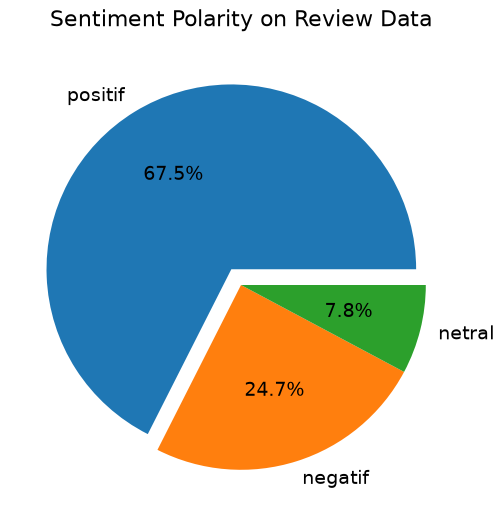

In [26]:
# Membuat objek gambar dan sumbu dengan ukuran (6, 6) inci
fig, ax = plt.subplots(figsize=(6, 6))
sizes = [count for count in df_clean['sentiment'].value_counts()]
labels = list(df_clean['sentiment'].value_counts().index)
explode = [0.1] + [0] * (len(sizes) - 1)

# Membuat pie chart 
ax.pie(x=sizes, labels=labels, autopct='%1.1f%%', explode=explode, textprops={'fontsize': 14})
ax.set_title('Sentiment Polarity on Review Data', fontsize=16, pad=20)
plt.show()

In [27]:
pd.set_option('display.max_colwidth', 3000)

# Membuat DataFrame baru 'positif' yang hanya berisi reviews dengan polaritas positif.
positif = df_clean[df_clean['sentiment'] == 'positif']

# Memilih hanya kolom-kolom tertentu dari DataFrame 'positif'.
positif = positif[['text_final', 'sentiment','text_stopword']]

# Mengatur ulang indeks DataFrame agar dimulai dari 0.
positif = positif.reset_index(drop=True)

# Menambahkan 1 ke semua indeks DataFrame.
positif.index += 1

In [28]:
pd.set_option('display.max_colwidth', 3000)

# Membuat DataFrame baru 'negatif' yang hanya berisi reviews dengan polaritas negatif.
negatif = df_clean[df_clean['sentiment'] == 'negatif']

# Memilih hanya kolom-kolom tertentu dari DataFrame 'negatif'.
negatif = negatif[['text_final', 'sentiment','text_stopword']]

# Mengatur ulang indeks DataFrame agar dimulai dari 0.
negatif = negatif.reset_index(drop=True)

# Menambahkan 1 ke semua indeks DataFrame.
negatif.index += 1

In [29]:
pd.set_option('display.max_colwidth', 3000)

# Membuat DataFrame baru 'netral' yang hanya berisi reviews dengan polaritas netral.
netral = df_clean[df_clean['sentiment'] == 'netral']

# Memilih hanya kolom-kolom tertentu dari DataFrame 'netral'.
netral = netral[['text_final', 'sentiment','text_stopword']]

# Mengatur ulang indeks DataFrame agar dimulai dari 0.
netral = netral.reset_index(drop=True)

# Menambahkan 1 ke semua indeks DataFrame.
netral.index += 1

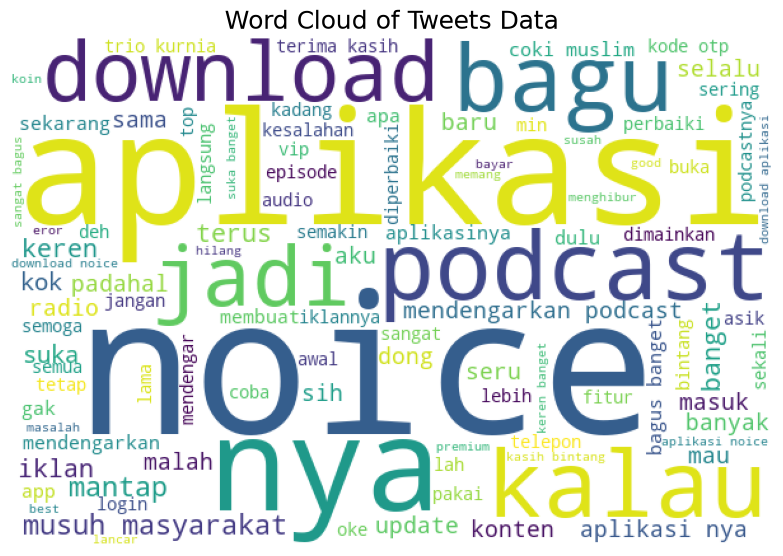

In [30]:
list_words = ''

# Iterasi melalui setiap tweet dalam kolom 'text_stopword' dari DataFrame 'df_clean'.
for tweet in df_clean['text_stopword']:
    # Iterasi melalui setiap kata dalam tweet.
    for word in tweet:
        # Menambahkan kata ke dalam 'list_words'.
        list_words += ' ' + (word)

# Membuat objek WordCloud dengan parameter tertentu.
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Membuat gambar dan sumbu untuk menampilkan word cloud.
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud.
ax.set_title('Word Cloud of Tweets Data', fontsize=18)

# Menonaktifkan grid pada sumbu.
ax.grid(False)

# Menampilkan word cloud dalam gambar.
ax.imshow((wordcloud))

# Mengatur layout gambar.
fig.tight_layout(pad=0)

# Menyembunyikan sumbu.
ax.axis('off')

# Menampilkan word cloud.
plt.show()

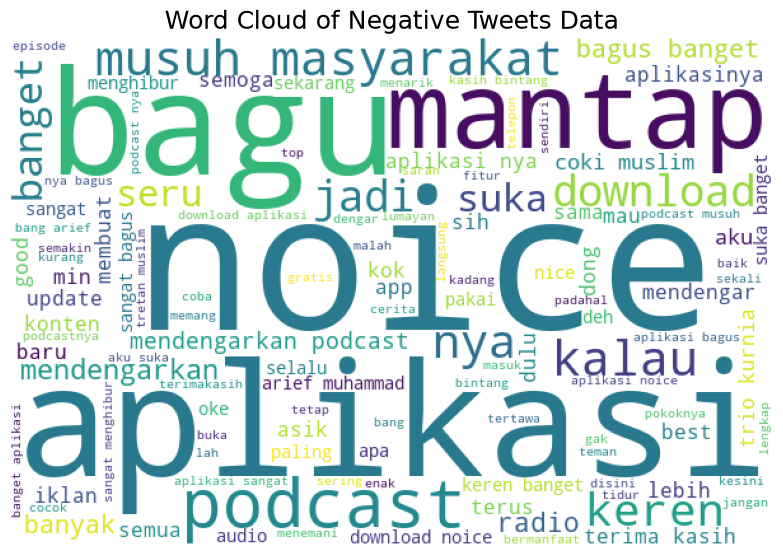

In [ ]:
# Membuat string kosong 'list_words' yang akan digunakan untuk mengumpulkan semua kata dari teks yang sudah dibersihkan dalam reviews positif.
list_words = ''

# Iterasi melalui setiap tweet dalam kolom 'text_stopword' dari DataFrame 'positif'.
for tweet in positif['text_stopword']:
    # Iterasi melalui setiap kata dalam tweet.
    for word in tweet:
        # Menambahkan kata ke dalam 'list_words'.
        list_words += ' ' + (word)

# Membuat objek WordCloud dengan parameter tertentu.
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Membuat gambar dan sumbu untuk menampilkan word cloud.
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud.
ax.set_title('Word Cloud of Negative Tweets Data', fontsize=18)

# Menonaktifkan grid pada sumbu.
ax.grid(False)

# Menampilkan word cloud dalam gambar.
ax.imshow((wordcloud))

# Mengatur layout gambar.
fig.tight_layout(pad=0)

# Menyembunyikan sumbu.
ax.axis('off')

# Menampilkan word cloud.
plt.show()

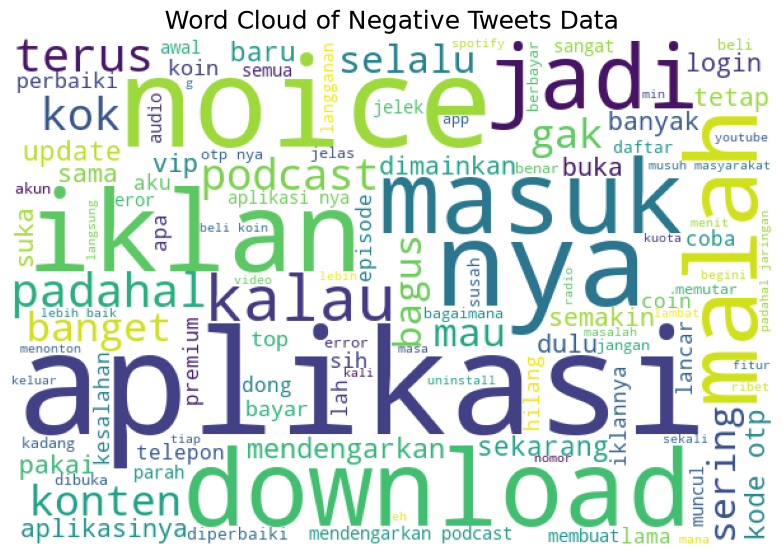

In [ ]:
# Membuat string kosong 'list_words' yang akan digunakan untuk mengumpulkan semua kata dari teks yang sudah dibersihkan dalam reviews negatif.
list_words = ''

# Iterasi melalui setiap tweet dalam kolom 'text_stopword' dari DataFrame 'negatif'.
for tweet in negatif['text_stopword']:
    # Iterasi melalui setiap kata dalam tweet.
    for word in tweet:
        # Menambahkan kata ke dalam 'list_words'.
        list_words += ' ' + (word)

# Membuat objek WordCloud dengan parameter tertentu.
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Membuat gambar dan sumbu untuk menampilkan word cloud.
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud.
ax.set_title('Word Cloud of Negative Tweets Data', fontsize=18)

# Menonaktifkan grid pada sumbu.
ax.grid(False)

# Menampilkan word cloud dalam gambar.
ax.imshow((wordcloud))

# Mengatur layout gambar.
fig.tight_layout(pad=0)

# Menyembunyikan sumbu.
ax.axis('off')

# Menampilkan word cloud.
plt.show()

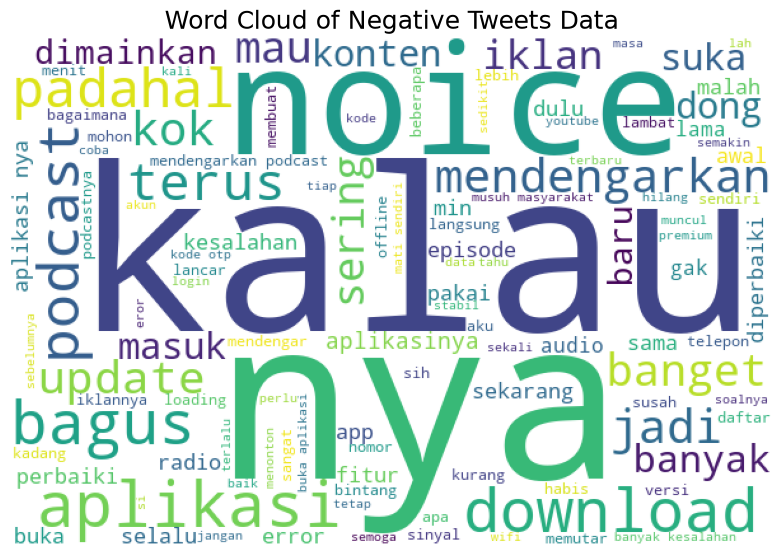

In [ ]:
# Membuat string kosong 'list_words' yang akan digunakan untuk mengumpulkan semua kata dari teks yang sudah dibersihkan dalam reviews netral.
list_words = ''

# Iterasi melalui setiap tweet dalam kolom 'text_stopword' dari DataFrame 'netral'.
for tweet in netral['text_stopword']:
    # Iterasi melalui setiap kata dalam tweet.
    for word in tweet:
        # Menambahkan kata ke dalam 'list_words'.
        list_words += ' ' + (word)

# Membuat objek WordCloud dengan parameter tertentu.
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Membuat gambar dan sumbu untuk menampilkan word cloud.
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud.
ax.set_title('Word Cloud of Negative Tweets Data', fontsize=18)

# Menonaktifkan grid pada sumbu.
ax.grid(False)

# Menampilkan word cloud dalam gambar.
ax.imshow((wordcloud))

# Mengatur layout gambar.
fig.tight_layout(pad=0)

# Menyembunyikan sumbu.
ax.axis('off')

# Menampilkan word cloud.
plt.show()

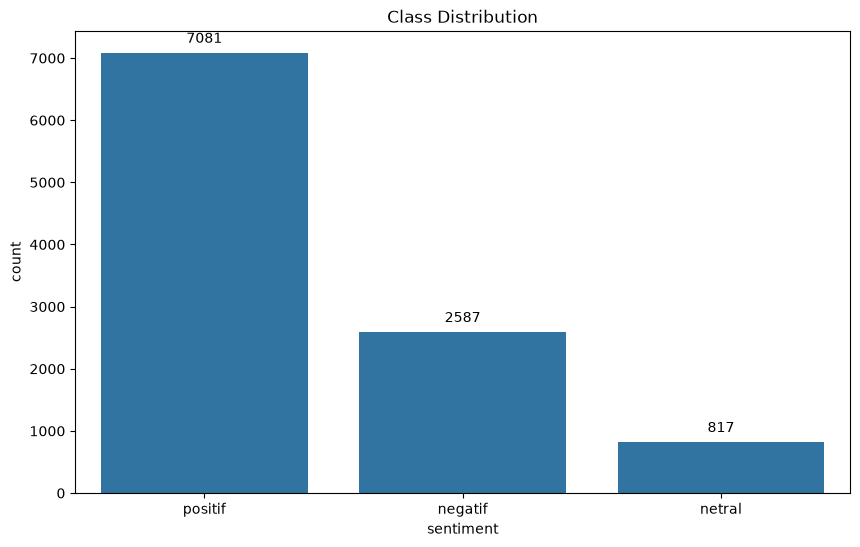

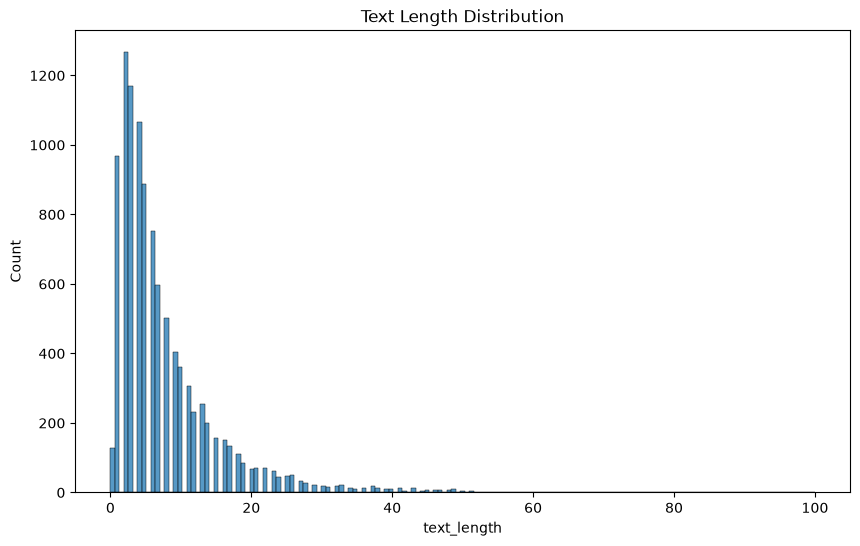

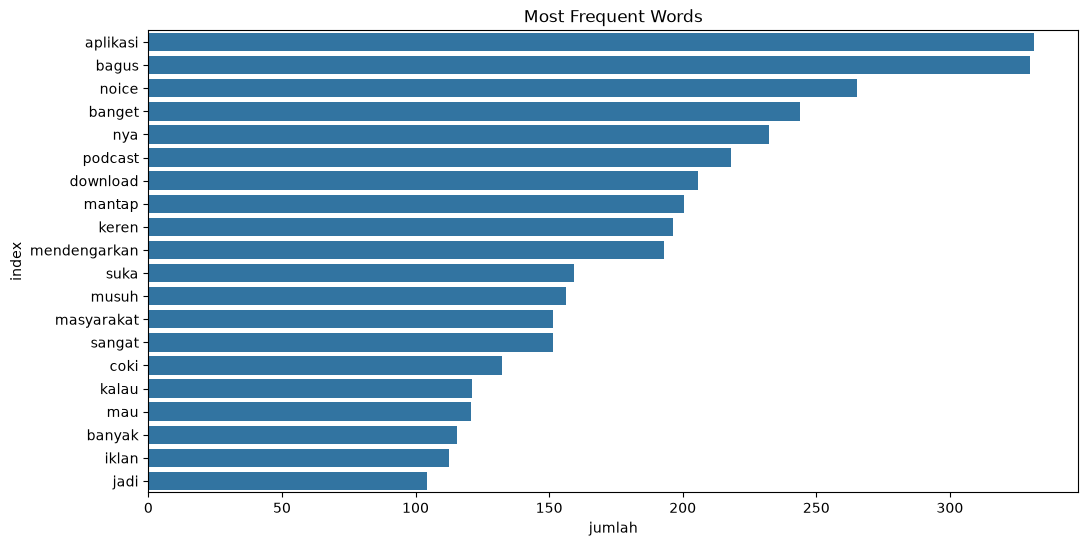

In [37]:
# Set the figure size
plt.figure(figsize=(10, 6))

# Check class distribution
class_dist_plot = sns.countplot(x='sentiment', data=df_clean)
plt.title('Class Distribution')

# Add counts above the bars on the plot
for p in class_dist_plot.patches:
    class_dist_plot.annotate(format(p.get_height(), '.0f'),
                              (p.get_x() + p.get_width() / 2., p.get_height()),
                              ha='center', va='center',
                              xytext=(0, 10),
                              textcoords='offset points')

plt.show()

# Set the figure size
plt.figure(figsize=(10, 6))

# Visualize text length distribution
df_clean['text_length'] = df_clean['text_final'].apply(lambda x: len(x.split()))
sns.histplot(df_clean['text_length'])
plt.title('Text Length Distribution')
plt.show()

# Set the figure size
plt.figure(figsize=(12, 6))

# Visualize most frequent words
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df_clean['text_final'])
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df = tfidf_df.sum().reset_index(name='jumlah')
tfidf_df = tfidf_df.sort_values('jumlah', ascending=False).head(20)
sns.barplot(x='jumlah', y='index', data=tfidf_df)
plt.title('Most Frequent Words')
plt.show()

# Feature Extraction

In [38]:
# Memisahkan data menjadi Fitur (X) dan Target (y)
X = df_clean['text_final']
y = df_clean['sentiment']

# Ekstraksi fitur dengan TF-IDF
tfidf = TfidfVectorizer(max_features=5000, min_df=3, max_df=0.8, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(X)

# Konversi hasil ekstraksi fitur menjadi dataframe
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())
 
# Menampilkan hasil ekstraksi fitur
features_df

,aamiin,abang,acak,acara,acaranya,ad,adain,adakan,adanya,add,...,youtube,youtube ig,youtube lancar,youtube spotify,yt,yt lancar,yu,yuk,yutub,zaman
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10480,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10481,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10482,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10483,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Data Splitting

In [39]:
# Bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# Modelling

# Naive Bayes

In [40]:
from sklearn.naive_bayes import MultinomialNB

# Membuat objek model Naive Bayes (Multinomial Naive Bayes)
naive_bayes = MultinomialNB()

# Melatih model Naive Bayes pada data pelatihan
naive_bayes.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_nb = naive_bayes.predict(X_train.toarray())
y_pred_test_nb = naive_bayes.predict(X_test.toarray())

# Evaluasi akurasi model Naive Bayes
accuracy_train_nb = accuracy_score(y_pred_train_nb, y_train)
accuracy_test_nb = accuracy_score(y_pred_test_nb, y_test)

# Menampilkan akurasi
print('Naive Bayes - accuracy_train:', accuracy_train_nb)
print('Naive Bayes - accuracy_test:', accuracy_test_nb)

Naive Bayes - accuracy_train: 0.8410824988078207
Naive Bayes - accuracy_test: 0.8068669527896996


# Random Forest

In [41]:
from sklearn.ensemble import RandomForestClassifier

# Membuat objek model Random Forest
random_forest = RandomForestClassifier()

# Melatih model Random Forest pada data pelatihan
random_forest.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_rf = random_forest.predict(X_train.toarray())
y_pred_test_rf = random_forest.predict(X_test.toarray())

# Evaluasi akurasi model Random Forest
accuracy_train_rf = accuracy_score(y_pred_train_rf, y_train)
accuracy_test_rf = accuracy_score(y_pred_test_rf, y_test)

# Menampilkan akurasi
print('Random Forest - accuracy_train:', accuracy_train_rf)
print('Random Forest - accuracy_test:', accuracy_test_rf)

Random Forest - accuracy_train: 0.9821173104434907
Random Forest - accuracy_test: 0.8054363376251789


# Logistic Regression

In [42]:
from sklearn.linear_model import LogisticRegression

# Membuat objek model Logistic Regression
logistic_regression = LogisticRegression(class_weight='balanced', max_iter=1000)

# Melatih model Logistic Regression pada data pelatihan
logistic_regression.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_lr = logistic_regression.predict(X_train.toarray())
y_pred_test_lr = logistic_regression.predict(X_test.toarray())

# Evaluasi akurasi model Logistic Regression pada data pelatihan
accuracy_train_lr = accuracy_score(y_pred_train_lr, y_train)

# Evaluasi akurasi model Logistic Regression pada data uji
accuracy_test_lr = accuracy_score(y_pred_test_lr, y_test)

# Menampilkan akurasi
print('Logistic Regression - accuracy_train:', accuracy_train_lr)
print('Logistic Regression - accuracy_test:', accuracy_test_lr)

Logistic Regression - accuracy_train: 0.8754172627563186
Logistic Regression - accuracy_test: 0.7734859322842156


# Decision Tree

In [43]:
from sklearn.tree import DecisionTreeClassifier

# Membuat objek model Decision Tree
decision_tree = DecisionTreeClassifier()

# Melatih model Decision Tree pada data pelatihan
decision_tree.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_dt = decision_tree.predict(X_train.toarray())
y_pred_test_dt = decision_tree.predict(X_test.toarray())

# Evaluasi akurasi model Decision Tree
accuracy_train_dt = accuracy_score(y_pred_train_dt, y_train)
accuracy_test_dt = accuracy_score(y_pred_test_dt, y_test)

# Menampilkan akurasi
print('Decision Tree - accuracy_train:', accuracy_train_dt)
print('Decision Tree - accuracy_test:', accuracy_test_dt)

Decision Tree - accuracy_train: 0.9821173104434907
Decision Tree - accuracy_test: 0.7496423462088698


In [48]:
from sklearn.svm import SVC

# Membuat objek model SVM
svm = SVC()

# Melatih model SVM pada data pelatihan
svm.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_svm = svm.predict(X_train.toarray())
y_pred_test_svm = svm.predict(X_test.toarray())

# Evaluasi akurasi model SVM
accuracy_train_svm = accuracy_score(y_pred_train_svm, y_train)
accuracy_test_svm = accuracy_score(y_pred_test_svm, y_test)

# Menampilkan akurasi
print('SVM - accuracy_train:', accuracy_train_svm)
print('SVM - accuracy_test:', accuracy_test_svm)

SVM - accuracy_train: 0.9256080114449213
SVM - accuracy_test: 0.8092513113972342


In [49]:
# Membuat DataFrame untuk hasil akurasi
results_df = pd.DataFrame({
    'Model': ['Naive Bayes', 'Random Forest', 'Logistic Regression', 'Decision Tree', 'Support Vector Machine'],
    'Accuracy Train': [accuracy_train_nb, accuracy_train_rf, accuracy_train_lr, accuracy_train_dt, accuracy_train_svm],
    'Accuracy Test': [accuracy_test_nb, accuracy_test_rf, accuracy_test_lr, accuracy_test_dt, accuracy_test_svm]
})

# Menampilkan hanya kolom "Accuracy Test"
accuracy_test_only = results_df[['Model', 'Accuracy Test']]
print(accuracy_test_only)

                    Model  Accuracy Test
0             Naive Bayes       0.806867
1           Random Forest       0.805436
2     Logistic Regression       0.773486
3           Decision Tree       0.749642
4  Support Vector Machine       0.809251
